# WEEK 1 Day 7 — Dataset Receipt & Initial Inspection
# LG HG2 18650 Li-ion Battery Dataset (McMaster University)
# Sreetama Santra | 12024052019052 | TIH IIT Guwahati | 2026-08-26

In [5]:
# Section 0: Imports and Configuration
import zipfile, io, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

# Paths
ZIP_PATH = "SOC DATA SET.zip"   # place the zip in working directory
OUT_DIR  = "inspection_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

TEMPS = ['40degC','25degC','10degC','0degC','n10degC','n20degC']
TEMP_LABELS = {'40degC':'40°C','25degC':'25°C','10degC':'10°C',
               '0degC':'0°C','n10degC':'−10°C','n20degC':'−20°C'}
TEMP_COLORS = {'40degC':'#e74c3c','25degC':'#e67e22','10degC':'#27ae60',
               '0degC':'#2980b9','n10degC':'#8e44ad','n20degC':'#2c3e50'}

HEADER_SKIP = 28  # metadata rows before column names
Q_NOMINAL   = 3.0  # Ah nominal capacity (will be refined from Cap files)

In [6]:
# Section 1: Raw Archive Inventory
print("=" * 60)
print("SECTION 1: RAW ARCHIVE INVENTORY")
print("=" * 60)

with zipfile.ZipFile(ZIP_PATH) as z:
    all_files = z.namelist()
    csvs = [f for f in all_files if f.endswith('.csv')]

    print(f"Total files in zip: {len(all_files)}")
    print(f"Total CSV files:    {len(csvs)}\n")

    # Count by temperature and type
    inventory = {}
    for f in csvs:
        parts = f.split('/')
        if len(parts) < 3:
            continue
        temp = parts[1]
        name = parts[2]
        ftype = 'Other'
        for t in ['Mixed','Charge','UDDS','HWFET','LA92','US06','HPPC','Cap','Dis']:
            if t in name:
                ftype = t
                break
        if temp not in inventory:
            inventory[temp] = {}
        inventory[temp][ftype] = inventory[temp].get(ftype, 0) + 1

    print(f"{'Temperature':<12} {'Mixed':>6} {'Charge':>7} {'Drive':>6} {'HPPC':>5} {'Cap/Dis':>8} {'Total':>6}")
    print("-" * 56)
    for t in TEMPS:
        inv = inventory.get(t, {})
        mixed   = inv.get('Mixed', 0)
        charge  = inv.get('Charge', 0)
        drive   = sum(inv.get(k,0) for k in ['UDDS','HWFET','LA92','US06'])
        hppc    = inv.get('HPPC', 0)
        capd    = inv.get('Cap', 0) + inv.get('Dis', 0)
        total   = sum(inv.values())
        print(f"{TEMP_LABELS[t]:<12} {mixed:>6} {charge:>7} {drive:>6} {hppc:>5} {capd:>8} {total:>6}")

SECTION 1: RAW ARCHIVE INVENTORY
Total files in zip: 211
Total CSV files:    208

Temperature   Mixed  Charge  Drive  HPPC  Cap/Dis  Total
--------------------------------------------------------
40°C              8      17      4     1        4     35
25°C              8      17      4     1        5     36
10°C              7      14      4     1        5     32
0°C               7      15      4     1        4     32
−10°C             8      19      4     1        5     38
−20°C             8      16      4     1        5     35


In [7]:
# Section 2: Load Representative Sample
print("\n" + "=" * 60)
print("SECTION 2: LOAD ONE MIXED FILE PER TEMPERATURE")
print("=" * 60)

def load_csv(z, path):
    with z.open(path) as f:
        raw = f.read().decode('latin-1').split('\n')
    for i, line in enumerate(raw):
        if 'Voltage' in line and 'Current' in line:
            header_row = i
            break
    df = pd.read_csv(io.StringIO('\n'.join(raw[header_row:])),
                     low_memory=False, encoding='latin-1')
    df.columns = [c.strip() for c in df.columns]
    for col in ['Voltage','Current','Temperature','Capacity','WhAccu','Cnt']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

samples = {}
with zipfile.ZipFile(ZIP_PATH) as z:
    csvs = [f for f in z.namelist() if f.endswith('.csv')]
    for temp in TEMPS:
        matches = [f for f in csvs if f'/{temp}/' in f and 'Mixed1' in f]
        if matches:
            df = load_csv(z, matches[0])
            samples[temp] = df
            n_total = len(df)
            n_pau   = len(df[df.get('Status', pd.Series()) == 'PAU']) if 'Status' in df.columns else 0
            n_null  = df[['Voltage','Current','Temperature','Capacity']].isnull().sum().sum()
            n_volt_bad = ((df['Voltage'] < 2.5) | (df['Voltage'] > 4.3)).sum()
            print(f"{TEMP_LABELS[temp]}: {n_total:,} rows | PAU rows: {n_pau} | "
                  f"NaN in key cols: {n_null} | Voltage outliers: {n_volt_bad}")


SECTION 2: LOAD ONE MIXED FILE PER TEMPERATURE
40°C: 75,342 rows | PAU rows: 6001 | NaN in key cols: 4 | Voltage outliers: 0
25°C: 77,228 rows | PAU rows: 6001 | NaN in key cols: 4 | Voltage outliers: 0
10°C: 72,330 rows | PAU rows: 6001 | NaN in key cols: 4 | Voltage outliers: 0
0°C: 67,313 rows | PAU rows: 6001 | NaN in key cols: 4 | Voltage outliers: 0
−10°C: 62,623 rows | PAU rows: 6001 | NaN in key cols: 4 | Voltage outliers: 0
−20°C: 45,344 rows | PAU rows: 6001 | NaN in key cols: 4 | Voltage outliers: 0


In [8]:
# Section 3: Summary Statistics
print("\n" + "=" * 60)
print("SECTION 3: FIRST-LOOK STATISTICS")
print("=" * 60)

print(f"\n{'Metric':<22}", end="")
for t in TEMPS:
    print(f"  {TEMP_LABELS[t]:>8}", end="")
print()
print("-" * 80)

for metric, col, agg in [
    ("Voltage min (V)",    "Voltage",     "min"),
    ("Voltage max (V)",    "Voltage",     "max"),
    ("Voltage mean (V)",   "Voltage",     "mean"),
    ("Current min (A)",    "Current",     "min"),
    ("Current max (A)",    "Current",     "max"),
    ("Temp min (°C)",      "Temperature", "min"),
    ("Temp max (°C)",      "Temperature", "max"),
    ("Capacity min (Ah)",  "Capacity",    "min"),
    ("Capacity max (Ah)",  "Capacity",    "max"),
]:
    print(f"{metric:<22}", end="")
    for t in TEMPS:
        df = samples[t]
        val = getattr(df[col], agg)() if col in df.columns else float('nan')
        print(f"  {val:>8.3f}", end="")
    print()


SECTION 3: FIRST-LOOK STATISTICS

Metric                      40°C      25°C      10°C       0°C     −10°C     −20°C
--------------------------------------------------------------------------------
Voltage min (V)            2.944     2.923     2.797     2.799     2.799     2.795
Voltage max (V)            4.200     4.201     4.202     4.202     4.202     4.201
Voltage mean (V)           3.724     3.696     3.679     3.651     3.595     3.552
Current min (A)          -16.469   -16.890   -16.418   -15.835   -11.999    -6.222
Current max (A)            6.002     6.000     6.005     3.070     3.050     1.578
Temp min (°C)             38.383    23.556     8.833    -0.736   -10.095   -19.980
Temp max (°C)             40.171    25.869    12.619     2.944    -6.310   -15.248
Capacity min (Ah)         -2.526    -2.590    -2.480    -2.350    -2.130    -1.588
Capacity max (Ah)         -0.000    -0.000    -0.000    -0.000    -0.000    -0.000


In [9]:
# Section 4: Missing Data and Duplicates
print("\n" + "=" * 60)
print("SECTION 4: MISSING DATA AND DUPLICATE CHECK")
print("=" * 60)

for temp in TEMPS:
    df = samples[temp]
    key_cols = ['Voltage','Current','Temperature','Capacity']
    missing = df[key_cols].isnull().sum()
    dups = df.duplicated(subset=['Voltage','Current','Temperature']).sum()
    print(f"\n{TEMP_LABELS[temp]}:")
    print(f"  Missing values: {missing.to_dict()}")
    print(f"  Duplicate rows (V,I,T match): {dups}")
    if 'Status' in df.columns:
        status_counts = df['Status'].value_counts().to_dict()
        print(f"  Status distribution: {status_counts}")


SECTION 4: MISSING DATA AND DUPLICATE CHECK

40°C:
  Missing values: {'Voltage': 1, 'Current': 1, 'Temperature': 1, 'Capacity': 1}
  Duplicate rows (V,I,T match): 23570
  Status distribution: {'TABLE': 69340, 'PAU': 6001}

25°C:
  Missing values: {'Voltage': 1, 'Current': 1, 'Temperature': 1, 'Capacity': 1}
  Duplicate rows (V,I,T match): 22511
  Status distribution: {'TABLE': 71226, 'PAU': 6001}

10°C:
  Missing values: {'Voltage': 1, 'Current': 1, 'Temperature': 1, 'Capacity': 1}
  Duplicate rows (V,I,T match): 19967
  Status distribution: {'TABLE': 66328, 'PAU': 6001}

0°C:
  Missing values: {'Voltage': 1, 'Current': 1, 'Temperature': 1, 'Capacity': 1}
  Duplicate rows (V,I,T match): 16503
  Status distribution: {'TABLE': 61311, 'PAU': 6001}

−10°C:
  Missing values: {'Voltage': 1, 'Current': 1, 'Temperature': 1, 'Capacity': 1}
  Duplicate rows (V,I,T match): 13397
  Status distribution: {'TABLE': 56621, 'PAU': 6001}

−20°C:
  Missing values: {'Voltage': 1, 'Current': 1, 'Temperatu

In [10]:
# Section 5: SoC Derivation Check
print("\n" + "=" * 60)
print("SECTION 5: SoC DERIVATION FEASIBILITY CHECK")
print("=" * 60)

for temp in TEMPS:
    df = samples[temp].copy()
    df = df[df.get('Status', 'TABLE') != 'PAU'] if 'Status' in df.columns else df
    cap = df['Capacity'].dropna()
    # Approximate SoC from Capacity resets
    n_resets = ((cap.diff() > 0.01) & (cap.shift(1) < 0)).sum()
    cap_range = cap.max() - cap.min()
    print(f"{TEMP_LABELS[temp]}: Capacity range = {cap_range:.4f} Ah | "
          f"Approx resets detected = {n_resets} | "
          f"SoC span ≈ {abs(cap_range)/Q_NOMINAL*100:.1f}%")


SECTION 5: SoC DERIVATION FEASIBILITY CHECK
40°C: Capacity range = 2.5255 Ah | Approx resets detected = 0 | SoC span ≈ 84.2%
25°C: Capacity range = 2.5901 Ah | Approx resets detected = 0 | SoC span ≈ 86.3%
10°C: Capacity range = 2.4796 Ah | Approx resets detected = 0 | SoC span ≈ 82.7%
0°C: Capacity range = 2.3497 Ah | Approx resets detected = 0 | SoC span ≈ 78.3%
−10°C: Capacity range = 2.1298 Ah | Approx resets detected = 0 | SoC span ≈ 71.0%
−20°C: Capacity range = 1.5879 Ah | Approx resets detected = 0 | SoC span ≈ 52.9%


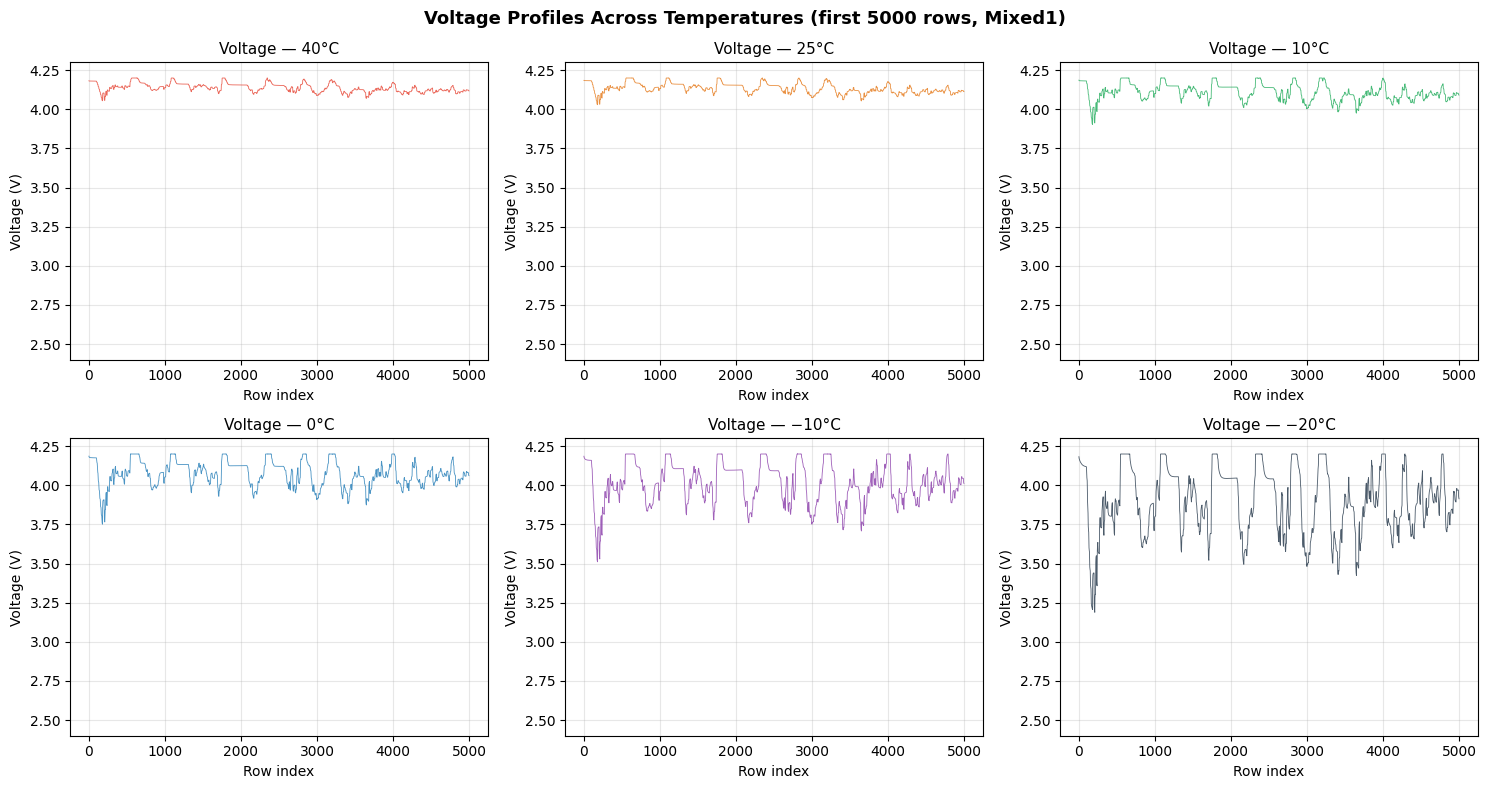

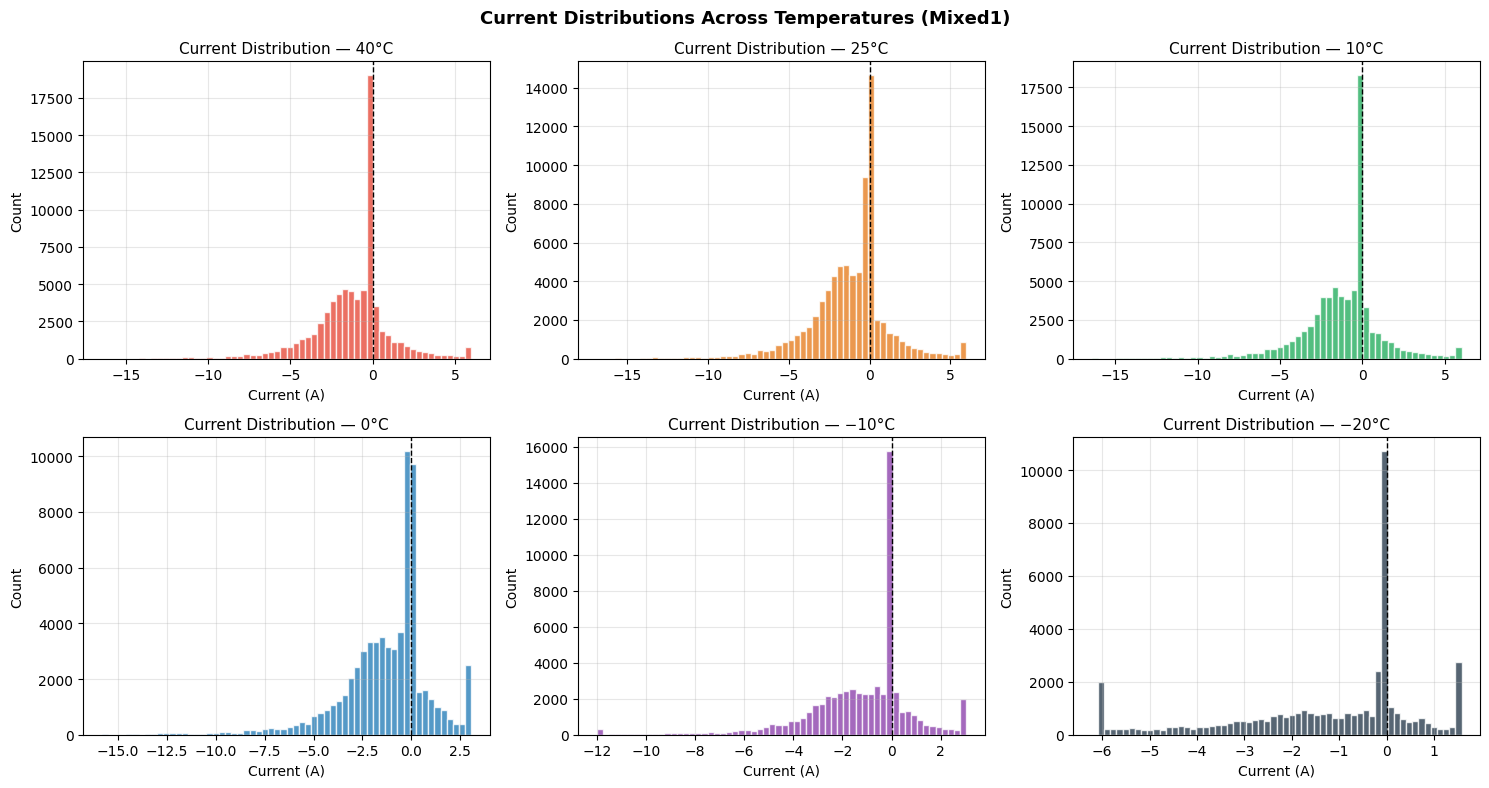

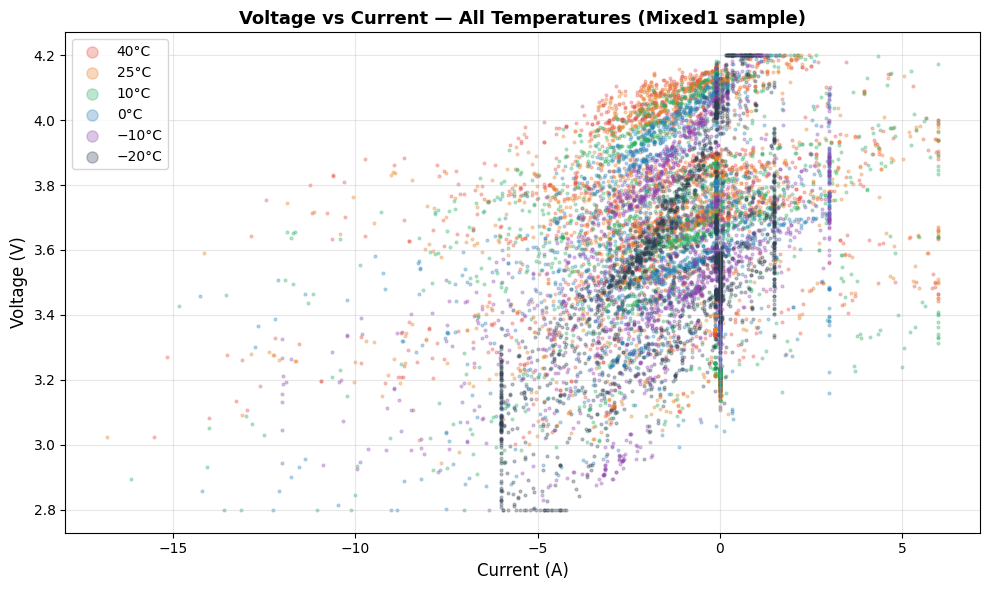

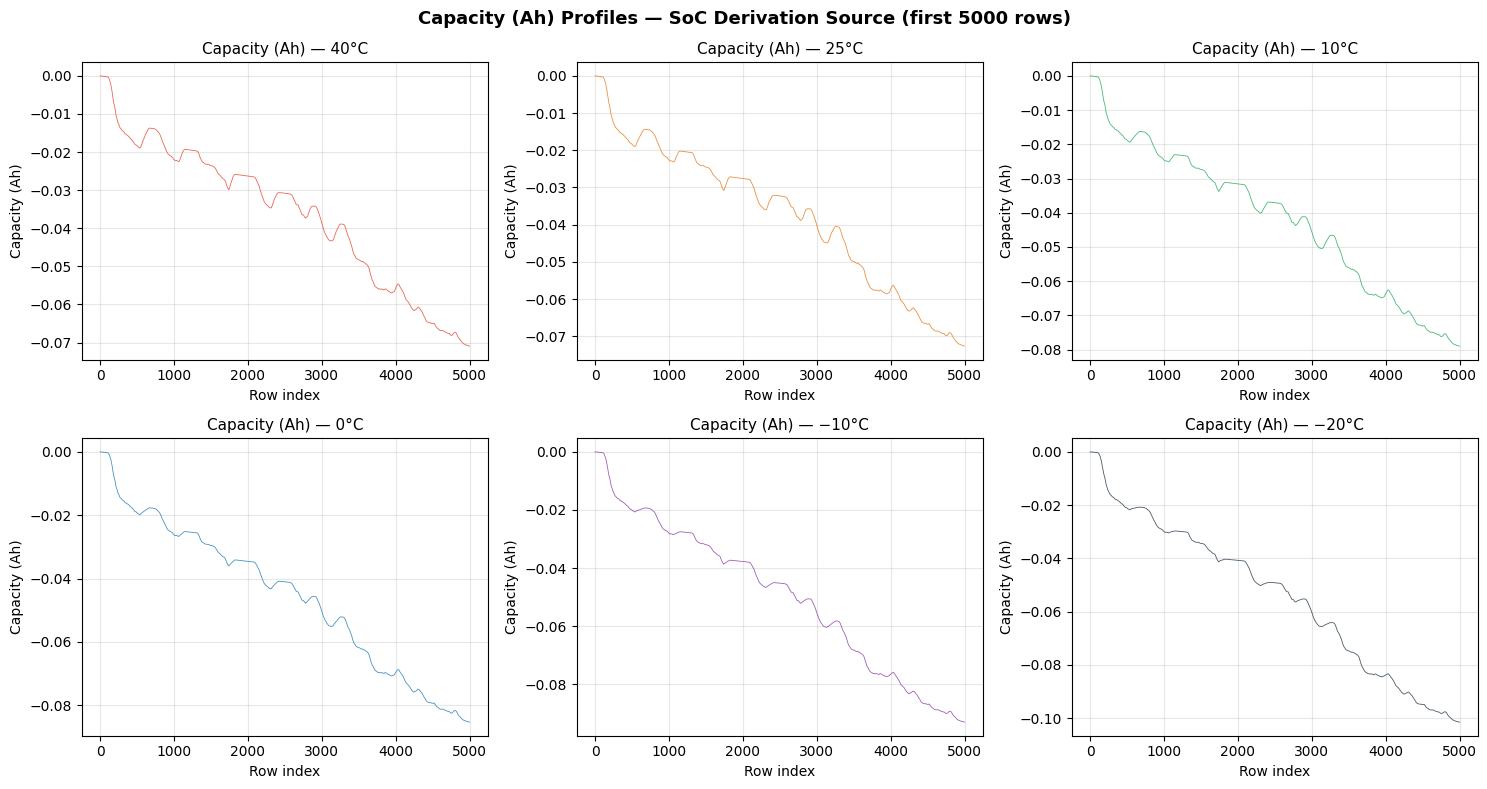

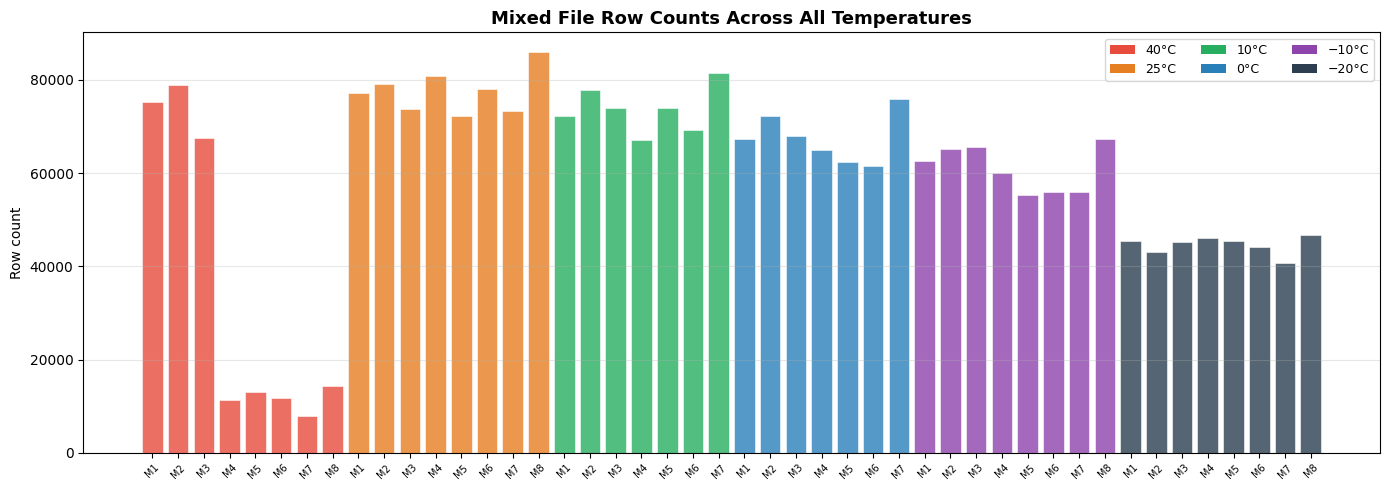

In [12]:
# Section 6: Plots

# Plot 1: Voltage profiles across temperatures
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, temp in enumerate(TEMPS):
    df = samples[temp].head(5000)
    axes[i].plot(df.index, df['Voltage'], color=TEMP_COLORS[temp], lw=0.6, alpha=0.85)
    axes[i].set_title(f'Voltage — {TEMP_LABELS[temp]}', fontsize=11)
    axes[i].set_xlabel('Row index')
    axes[i].set_ylabel('Voltage (V)')
    axes[i].set_ylim(2.4, 4.3)
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Voltage Profiles Across Temperatures (first 5000 rows, Mixed1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: Current distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, temp in enumerate(TEMPS):
    df = samples[temp]
    curr = df['Current'].dropna()
    axes[i].hist(curr, bins=60, color=TEMP_COLORS[temp], alpha=0.8, edgecolor='white', lw=0.3)
    axes[i].set_title(f'Current Distribution — {TEMP_LABELS[temp]}', fontsize=11)
    axes[i].set_xlabel('Current (A)')
    axes[i].set_ylabel('Count')
    axes[i].axvline(0, color='black', lw=1, linestyle='--')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Current Distributions Across Temperatures (Mixed1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: Voltage vs Current scatter
fig, ax = plt.subplots(figsize=(10, 6))
for temp in TEMPS:
    df = samples[temp].sample(min(2000, len(samples[temp])), random_state=42)
    ax.scatter(df['Current'], df['Voltage'],
               c=TEMP_COLORS[temp], label=TEMP_LABELS[temp],
               alpha=0.3, s=4)
ax.set_xlabel('Current (A)', fontsize=12)
ax.set_ylabel('Voltage (V)', fontsize=12)
ax.set_title('Voltage vs Current — All Temperatures (Mixed1 sample)', fontsize=13, fontweight='bold')
ax.legend(markerscale=4, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: Capacity profiles
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, temp in enumerate(TEMPS):
    df = samples[temp].head(5000)
    axes[i].plot(df.index, df['Capacity'], color=TEMP_COLORS[temp], lw=0.6, alpha=0.85)
    axes[i].set_title(f'Capacity (Ah) — {TEMP_LABELS[temp]}', fontsize=11)
    axes[i].set_xlabel('Row index')
    axes[i].set_ylabel('Capacity (Ah)')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Capacity (Ah) Profiles — SoC Derivation Source (first 5000 rows)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 5: Row counts per file across temperatures
with zipfile.ZipFile(ZIP_PATH) as z:
    csvs_all = [f for f in z.namelist() if f.endswith('.csv')]
    mixed_files = [f for f in csvs_all if 'Mixed' in f.split('/')[-1]]
    row_counts = {}
    for temp in TEMPS:
        tfiles = [f for f in mixed_files if f'/{temp}/' in f]
        counts = []
        for tf in tfiles:
            df = load_csv(z, tf)
            counts.append(len(df))
        row_counts[temp] = counts

fig, ax = plt.subplots(figsize=(14, 5))
x = 0
positions, labels, data, colors = [], [], [], []
for temp in TEMPS:
    for j, cnt in enumerate(row_counts[temp]):
        positions.append(x)
        labels.append(f"M{j+1}")
        data.append(cnt)
        colors.append(TEMP_COLORS[temp])
        x += 1
    x += 0.8

ax.bar(range(len(data)), data, color=colors, alpha=0.8, edgecolor='white', lw=0.5)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(labels, fontsize=7, rotation=45)
ax.set_ylabel('Row count')
ax.set_title('Mixed File Row Counts Across All Temperatures', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=TEMP_COLORS[t], label=TEMP_LABELS[t]) for t in TEMPS]
ax.legend(handles=legend_elements, fontsize=9, ncol=3)
plt.tight_layout()
plt.show()